# **Importação dos Dados da Telemetria**

In [ ]:
import pandas as pd

df = pd.read_csv('./telemetria_decolagem.csv')

# **Análise dos Dados da Telemetria**


In [ ]:
print("\n" +"=" * 50)
print(" Relatório da Telemetria: ")

print(f" Total de naves: {len(df)}")
print(f" Parâmetros analisados: {len(df.columns)}")

print("\n" +"=" * 50)
print(" Parâmetros Monitorados:")
print("=" * 50)

print(f"\n  Temperatura Interna:")
print(f"  Faixa Segura: 18°C a 27°C")
print(f"  Média da Temperatura das Naves: {df['temp_interna_C'].mean():.2f}°C")

print(f"\n  Temperatura Externa:")
print(f"  Faixa Segura: -40°C a 80°C")
print(f"  Média da Temperatura das Naves: {df['temp_externa_C'].mean():.2f}°C")

print(f"\n  Integridade Estrutural:")
print(f"  1 == OK e 0 == FALHA")
print(f"  Naves com a integridade OK: {len(df[df['integridade']== 1])} naves")
print(f"  Naves com a integridade FALHA: {len(df[df['integridade']== 0])} naves")


print(f"\n  Nível de Energia:")
print(f"  Faixa Segura > 40%")
print(f"  Média de Níveis de Energia: {df['energia_pct'].mean():.2f}" )

print(f"\n  Pressão nos Tanques:")
print(f"  Faixa Segura 1.5 a 3.0")
print(f"  Média da pressura dos tanque: {df['pressao_bar'].mean():.2f}" )
# Análise Energética
print("\n  Analise Energética: ")

df['cargaDisponivelKwh'] = df["capacidade_total_kwh"] * (df["energia_pct"] /100 )
df["energiaNecessariaParaDecolagem"] = df["consumo_decolagem_kwh"] * (1 + df["perdas_pct"] /100)
df["autonomia"] = df["cargaDisponivelKwh"] >=  df["energiaNecessariaParaDecolagem"]

print(f"  Carga disponível média: {df["cargaDisponivelKwh"].mean():.2f}")
print(f"  Energia necessária disponível média: {df["energiaNecessariaParaDecolagem"].mean():.2f}")
print(f"  Naves com energia suficiente para decolagem: {df["autonomia"].sum()}" )
print(f"  Naves com energia insuficiente para decolagem: {(~df["autonomia"]).sum()}" )

print(f"\n  Status Módulos Críticos:")

def gerarStatus(linha):
  if(linha['integridade'] == 0 or
     linha['energia_pct'] < 20 or
     linha['pressao_bar'] < 1.0 or
     linha['temp_interna_C'] > 35):
    return "critico"

  if(linha['energia_pct'] < 40 or
      linha['pressao_bar'] < 1.5 or
      linha['temp_interna_C'] > 27):
    return "alerta"
  return 'Ok'

df['status_modulo'] = df.apply(gerarStatus, axis=1)


print(f"  OK: {len(df[df['status_modulo'] == 'Ok'])} naves")
print(f"  Alerta: {len(df[df['status_modulo'] == 'alerta'])} naves")
print(f"  Crítico: {len(df[df['status_modulo'] == 'critico'])} naves")






 Relatório da Telemetria: 
 Total de naves: 500
 Parâmetros analisados: 9

 Parâmetros Monitorados:

  Temperatura Interna:
  Faixa Segura: 18°C a 27°C
  Média da Temperatura das Naves: 26.30°C

  Temperatura Externa:
  Faixa Segura: -40°C a 80°C
  Média da Temperatura das Naves: -1.40°C

  Integridade Estrutural:
  1 == OK e 0 == FALHA
  Naves com a integridade OK: 444 naves
  Naves com a integridade FALHA: 56 naves

  Nível de Energia:
  Faixa Segura > 40%
  Média de Níveis de Energia: 59.71

  Pressão nos Tanques:
  Faixa Segura 1.5 a 3.0
  Média da pressura dos tanque: 1.88

  Analise Energética: 
  Carga disponível média: 594.99
  Energia necessária disponível média: 300.41
  Naves com energia suficiente para decolagem: 427
  Naves com energia insuficiente para decolagem: 73

  Status Módulos Críticos:
  OK: 296 naves
  Alerta: 112 naves
  Crítico: 92 naves


# **Algoritmo de Decisão Baseado nas Faixa de Segurança**
Algoritmo de Verificação:

In [ ]:
def retornaDecolagem(linha):
    if linha["temp_interna_C"] < 18 or linha['temp_interna_C'] > 27:
        return "DECOLAGEM ABORTADA"
    if linha["temp_externa_C"] < -40 or linha["temp_externa_C"] > 80:
        return "DECOLAGEM ABORTADA"
    if linha["integridade"] == 0:
        return "DECOLAGEM ABORTADA"
    if linha["energia_pct"] < 40:
        return "DECOLAGEM ABORTADA"
    if linha["pressao_bar"] < 1.5 or linha["pressao_bar"] > 3.0:
        return "DECOLAGEM ABORTADA"
    if not linha["autonomia"]:
        return "DECOLAGEM ABORTADA"
    if linha['status_modulo'] == 'critico':
        return 'DECOLAGEM ABORTADA'
    return "PRONTO PARA DECOLAR"




# **Resultado do Algoritmo de Verificação, baseado nas Faixas de Segurança**

In [ ]:
df["decisao"] = df.apply(retornaDecolagem, axis = 1)

print("\n" +"=" * 50)
print(f"  Decisão para a decolagem:")
print("=" * 50)


print(f"\n OK para decolagem: {len(df[df['decisao'] == 'PRONTO PARA DECOLAR'])} naves")
print(f" Decolagem abortada: {len(df[df['decisao'] == 'DECOLAGEM ABORTADA'])} naves")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

print("\n" +"=" * 50)
print("   Relatório Separado por Nave:")
print("=" * 50)
print(df[['nave_id', 'temp_interna_C', 'temp_externa_C', 'energia_pct', 'pressao_bar', 'integridade', 'status_modulo', 'decisao']])

print("\n" +"=" * 50)
print("   Naves prontas para decolagem:")
print("=" * 50)
print(df[df['decisao'] == 'PRONTO PARA DECOLAR'][['nave_id', 'energia_pct',
                                      'pressao_bar', 'status_modulo']])







  Decisão para a decolagem:

 OK para decolagem: 154 naves
 Decolagem abortada: 346 naves

   Relatório Separado por Nave:
      nave_id  temp_interna_C  temp_externa_C  energia_pct  pressao_bar  \
0    NAVE-001           22.22           79.54        64.79         1.77   
1    NAVE-002           22.69           49.57        46.76         1.91   
2    NAVE-003           25.84           31.81        82.00         2.10   
3    NAVE-004           24.60           15.85        65.89         2.08   
4    NAVE-005           38.55          -29.20         9.95         0.63   
5    NAVE-006           22.80           78.41        70.88         2.39   
6    NAVE-007           24.56           73.99        70.35         2.39   
7    NAVE-008           26.99          -38.64        52.80         1.20   
8    NAVE-009           36.66         -112.37        13.94         0.95   
9    NAVE-010           22.47          -35.67        85.88         2.01   
10   NAVE-011           23.03           93.80      

##**Análise Assistida por IA:**
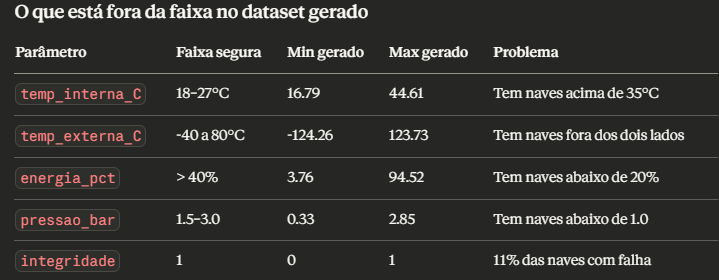

#**Análise Crítica**

A exploração espacial no geral, se para expansão quanto para novas descobertas exige uma ética de responsabilidade que supere a ausência de leis propostas para novas tecnologias que vem surgindo, garantindo que essas novas tecnologias não atropele direitos humanos.
O alto investimento na exploração espacial não pode encobrir os problemas que temos na terra como por exemplo: água limpa, energia e etc.
Em resumo não podemos querer almejar uma exploração espacial sem antes resolver os problemas na terra, devemos conciliar tais problemas, as leis devem andar rente a evolução da tecnologia sem afetar os direitos humanos.
